/tmp/ipykernel_29588/2680433817.py:109: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


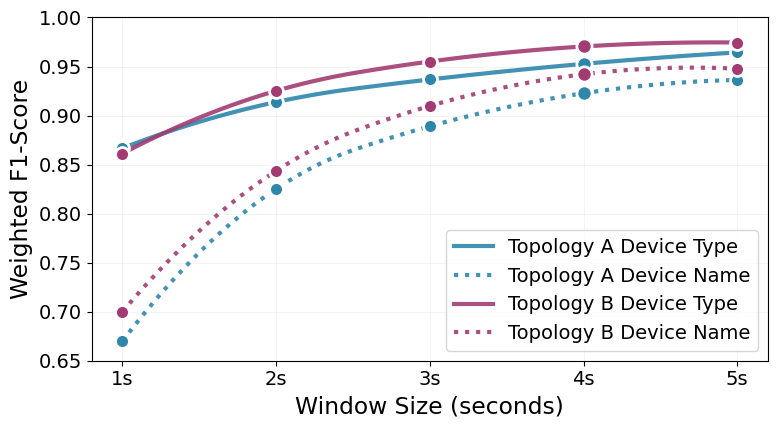

In [35]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib as mpl


mpl.rcdefaults()
plt.rcParams.update({'font.size': 14})





# Data from the table
window_sizes = np.array([1, 2, 3, 5])  # Window sizes in seconds

# Topology A data
A_type_classification = np.array([0.8667, 0.9138, 0.9368, 0.9644])
A_name_classification = np.array([0.6700, 0.8252, 0.8891, 0.9363])

# Topology B data
B_type_classification = np.array([0.8612, 0.9252, 0.9551, 0.9745])
B_name_classification = np.array([0.6999, 0.8436, 0.9098, 0.9478])

# Create interpolation functions
interp_A_type = interp1d(window_sizes, A_type_classification, kind='quadratic')
interp_A_name = interp1d(window_sizes, A_name_classification, kind='quadratic')
interp_B_type = interp1d(window_sizes, B_type_classification, kind='quadratic')
interp_B_name = interp1d(window_sizes, B_name_classification, kind='quadratic')

# Extended arrays
window_sizes_smooth = np.linspace(1, 5, 100)

# Interpolate smooth curves
A_type_smooth = interp_A_type(window_sizes_smooth)
A_name_smooth = interp_A_name(window_sizes_smooth)
B_type_smooth = interp_B_type(window_sizes_smooth)
B_name_smooth = interp_B_name(window_sizes_smooth)

# Calculate interpolated 4s values
A_type_4s = interp_A_type(4)
A_name_4s = interp_A_name(4)
B_type_4s = interp_B_type(4)
B_name_4s = interp_B_name(4)

# Define enhanced colors
color_A = '#2E86AB'  # Deep Blue for Topology A
color_B = '#A23B72'  # Purple/Magenta for Topology B
linestyle_type = '-'  # Solid line for Device Type
linestyle_name = ':'  # Dotted line for Device Name

# ========== FIGURE 1: All curves together ==========
fig, ax1 = plt.subplots(figsize=(8,4.5), layout="constrained")

# Plot Topology A - Device Type
ax1.plot(window_sizes_smooth, A_type_smooth, 
         color=color_A, linestyle=linestyle_type, linewidth=3,
         label='Topology A Device Type', alpha=0.9)
ax1.scatter(window_sizes, A_type_classification, 
           color=color_A, s=100, zorder=5, edgecolors='white', linewidth=2)
ax1.scatter(4, A_type_4s, color=color_A, s=120, 
           edgecolors='white', linewidth=2, zorder=6)

# Plot Topology A - Device Name
ax1.plot(window_sizes_smooth, A_name_smooth, 
         color=color_A, linestyle=linestyle_name, linewidth=3,
         label='Topology A Device Name', alpha=0.9)
ax1.scatter(window_sizes, A_name_classification, 
           color=color_A, s=100, zorder=5, edgecolors='white', linewidth=2)
ax1.scatter(4, A_name_4s, color=color_A, s=120, 
           edgecolors='white', linewidth=2, zorder=6)

# Plot Topology B - Device Type
ax1.plot(window_sizes_smooth, B_type_smooth, 
         color=color_B, linestyle=linestyle_type, linewidth=3,
         label='Topology B Device Type', alpha=0.9)
ax1.scatter(window_sizes, B_type_classification, 
           color=color_B, s=100, zorder=5, edgecolors='white', linewidth=2)
ax1.scatter(4, B_type_4s, color=color_B, s=120, 
           edgecolors='white', linewidth=2, zorder=5)

# Plot Topology B - Device Name
ax1.plot(window_sizes_smooth, B_name_smooth, 
         color=color_B, linestyle=linestyle_name, linewidth=3,
         label='Topology B Device Name', alpha=0.9)
ax1.scatter(window_sizes, B_name_classification, 
           color=color_B, s=100, zorder=5, edgecolors='white', linewidth=2)
ax1.scatter(4, B_name_4s, color=color_B, s=120,
           edgecolors='white', linewidth=2, zorder=6)

# Customize first figure
ax1.set_xlabel('Window Size (seconds)', fontsize='large')
ax1.set_ylabel('Weighted F1-Score',fontsize='large')
# ax1.set_title('Weighted F1-Score - All Classifications Combined', fontsize=14, fontweight='bold')
ax1.set_xticks([1, 2, 3, 4, 5])
ax1.set_xticklabels(['1s', '2s', '3s', '4s', '5s'])
ax1.set_ylim(0.65, 1.0)
ax1.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax1.legend(loc='lower right', fontsize='medium',
    title_fontsize='large',
    frameon=True,
    fancybox=True,)




plt.tight_layout()
plt.savefig('f1_score_all_combined.pdf', dpi=300, bbox_inches='tight')
plt.show()


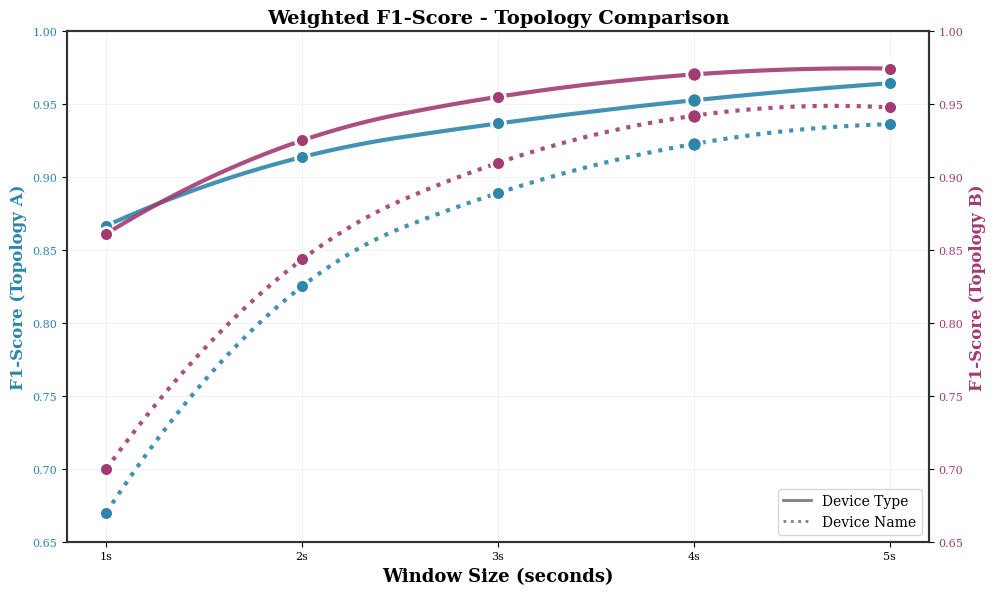


Two separate figures generated successfully!

Figure 1: All four curves on the same plot
Figure 2: Separated view by topology for clarity

Key features:
- Diamond markers (◆) indicate interpolated points at 4s
- Shaded region highlights the interpolated area (Figure 1)
- Different colors: Blue (Topology A) vs Purple (Topology B)
- Different line styles: Solid (Device Type) vs Do


In [21]:

# ========== FIGURE 2: Separated by topology ==========
fig2, ax2 = plt.subplots(figsize=(10, 6))

# Create two y-axes for better visualization
ax2_top = ax2
ax2_bottom = ax2.twinx()

# Plot Topology A on top axis
ax2_top.plot(window_sizes_smooth, A_type_smooth, 
            color=color_A, linestyle=linestyle_type, linewidth=3,
            label='Device Type', alpha=0.9)
ax2_top.plot(window_sizes_smooth, A_name_smooth, 
            color=color_A, linestyle=linestyle_name, linewidth=3,
            label='Device Name', alpha=0.9)
ax2_top.scatter(window_sizes, A_type_classification, 
               color=color_A, s=100, zorder=5, edgecolors='white', linewidth=2)
ax2_top.scatter(window_sizes, A_name_classification, 
               color=color_A, s=100, zorder=5, edgecolors='white', linewidth=2)
ax2_top.scatter(4, A_type_4s, color=color_A, s=120, 
               edgecolors='white', linewidth=2, zorder=6)
ax2_top.scatter(4, A_name_4s, color=color_A, s=120,
               edgecolors='white', linewidth=2, zorder=6)

# Plot Topology B on bottom axis
ax2_bottom.plot(window_sizes_smooth, B_type_smooth, 
               color=color_B, linestyle=linestyle_type, linewidth=3,
               alpha=0.9)
ax2_bottom.plot(window_sizes_smooth, B_name_smooth, 
               color=color_B, linestyle=linestyle_name, linewidth=3,
               alpha=0.9)
ax2_bottom.scatter(window_sizes, B_type_classification, 
                  color=color_B, s=100, zorder=5, edgecolors='white', linewidth=2)
ax2_bottom.scatter(window_sizes, B_name_classification, 
                  color=color_B, s=100, zorder=5, edgecolors='white', linewidth=2)
ax2_bottom.scatter(4, B_type_4s, color=color_B, s=120,
                  edgecolors='white', linewidth=2, zorder=6)
ax2_bottom.scatter(4, B_name_4s, color=color_B, s=120,
                  edgecolors='white', linewidth=2, zorder=6)

# Customize second figure
ax2_top.set_xlabel('Window Size (seconds)', fontsize=13, fontweight='bold')
ax2_top.set_ylabel('F1-Score (Topology A)', fontsize=12, color=color_A, fontweight='bold')
ax2_bottom.set_ylabel('F1-Score (Topology B)', fontsize=12, color=color_B, fontweight='bold')
ax2_top.set_title('Weighted F1-Score - Topology Comparison', fontsize=14, fontweight='bold')
ax2_top.set_xticks([1, 2, 3, 4, 5])
ax2_top.set_xticklabels(['1s', '2s', '3s', '4s', '5s'])
ax2_top.set_ylim(0.65, 1.0)
ax2_bottom.set_ylim(0.65, 1.0)
ax2_top.tick_params(axis='y', labelcolor=color_A)
ax2_bottom.tick_params(axis='y', labelcolor=color_B)
ax2_top.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)

# Add custom legend for second figure
legend_elements = [Line2D([0], [0], color='gray', lw=2, linestyle='-', label='Device Type'),
                   Line2D([0], [0], color='gray', lw=2, linestyle=':', label='Device Name'),]
ax2_top.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
# plt.savefig('f1_score_topology_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nTwo separate figures generated successfully!")
print("\nFigure 1: All four curves on the same plot")
print("Figure 2: Separated view by topology for clarity")
print("\nKey features:")
print("- Diamond markers (◆) indicate interpolated points at 4s")
print("- Shaded region highlights the interpolated area (Figure 1)")
print("- Different colors: Blue (Topology A) vs Purple (Topology B)")
print("- Different line styles: Solid (Device Type) vs Do")